In [6]:
from src.dataloading import EpiConfig, EpiDataOrchestrator
# get data
disease_name    = 'influenza'
nuts_level      = 'nuts3'
min_date        = '2011-06-01'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 3
sequence_length = 4
lag_num         = 4

config = EpiConfig(
    disease             = disease_name,

    min_date            = min_date,
    max_date            = max_date,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest, 

    quantiles           = [0.1,0.25, 0.5, 0.75, 0.9],
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,

    nuts_level          = nuts_level,
    log_transform       = ['incidence'],
    split_berlin        = split_berlin,

    target_column       = 'incidence',
    lag_column          = 'incidence',  
    verbose             = 0  ,

    feature_popdens     = True,
    feature_gisd        = True,
    feature_popage      = True,
    )    


epidata_orchestrator  = (EpiDataOrchestrator(config)
                      .load_raw()
                      .harmonize_raw()
                      .process_data()
                      .build_features()
                      .normalize()
                      .finalize()
                      )

n_epochs        = 500
lr              = 0.0001
min_delta       = 0.0001
loss            = 'pinball'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

In [ ]:
from src.dataloading import BaseLineDataLoaderManager, GraphDataLoaderManager
baselinedata             = BaseLineDataLoaderManager(epidata_orchestrator)



graphdataloader_1       = GraphDataLoaderManager(epidata_orchestrator).retrieve_static_graph('test1').build()
graphdataloader_2       = GraphDataLoaderManager(epidata_orchestrator).retrieve_static_graph('test2').build()
graphdataloader_3     = GraphDataLoaderManager(epidata_orchestrator).retrieve_static_graph('test3').build()

from src.models import LSTMModel
from src.dataloading import DeepDataLoaderManager

deepdataloader     = DeepDataLoaderManager(epidata_orchestrator).build()
graphdataloader_4     = GraphDataLoaderManager(epidata_orchestrator).retrieve_static_graph('test4').build()


In [3]:
from src.models import SimpleGCNModel, GCNTCNModel

In [4]:
from src.models import ClimaScaleModel, PersistenceModel, ClimateologyModel 
from src.evaluation import Evaluator

persistence = PersistenceModel(baselinedata)
persistence.forecast()

# climateology = ClimateologyModel(baselinedata)
# climateology.forecast()

# climascale = ClimaScaleModel(baselinedata)
# climascale.forecast()

baseline_models = [persistence]

In [ ]:
ml1 = GCNTCNModel(graphdataloader_1, name = 'model1',verbose = 2)
ml1.set_model_hparams(norm_edges=True)
ml1.set_global_hparams(**global_hparams)
ml1.train()
ml1.forecast()


==                    model1                    ==
model_hparams_set ✓


ValueError: quantiles given to DeepModel, yet loss is not pinball.


==                   model1+                    ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 25, 4), y=(400, 1), edge_index=(2, 2088), edge_weight=(2088,))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   0.8302   |   0.9773   |    v     |           |
|  002  |   0.6718   |   0.7798   |    v     |           |
|  003  |   0.6099   |   0.7047   |    v     |           |
|  004  |   0.5682   |   0.6592   |    v     |           |
|  005  |   0.5401   |   0.6277   |    v     |           |
|  006  |   0.5194   |   0.5961   |    v     |           |
|  007  |   0.5002   |   0.5748   |    v     |           |
|  008  |   0.4907   |   0.5628   |    v     |           |
|  009  |   0.4833   |   0.5378   |    v     |           |
|  010  |   0.4734   |   0.5229   |    v     |           |
|  011  |   0.4685   |   0.5148   |    v     |           |
|  012  |   0.4604   |   0.4988   |   

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:335: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 15 epochs
Restored model from best validation loss: 0.3758
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 292.14it/s]


Test loss: 0.6165
forecasted ✓


GCNTCNModel(name='model1+')

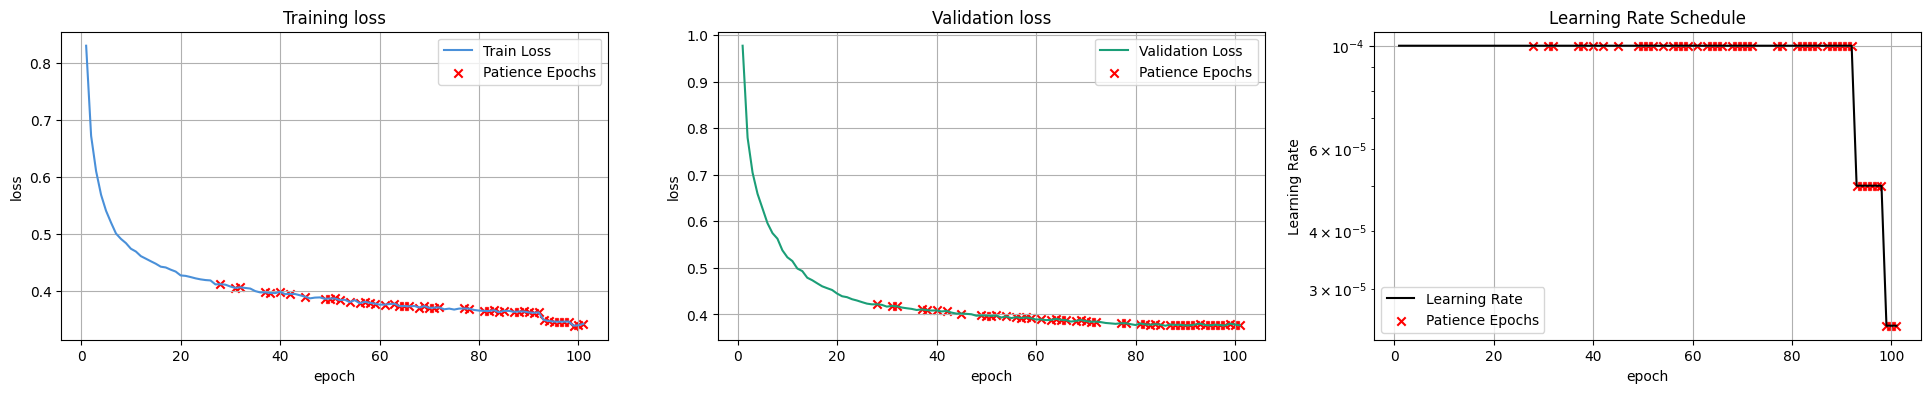

In [ ]:
ml2 = GCNTCNModel(graphdataloader_1, name = 'model1+',verbose = 2)
ml2.set_model_hparams(self_loops=True, norm_edges=True)
ml2.set_global_hparams(**global_hparams)
ml2.train()
ml2.forecast()


==                    model3                    ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 25, 4), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   0.8287   |   1.0136   |    v     |           |
|  002  |   0.6629   |   0.7600   |    v     |           |
|  003  |   0.5779   |   0.6533   |    v     |           |
|  004  |   0.5357   |   0.6077   |    v     |           |
|  005  |   0.5116   |   0.5767   |    v     |           |
|  006  |   0.4937   |   0.5541   |    v     |           |
|  007  |   0.4822   |   0.5510   |    v     |           |
|  008  |   0.4736   |   0.5402   |    v     |           |
|  009  |   0.4627   |   0.5216   |    v     |           |
|  010  |   0.4586   |   0.5179   |    v     |           |
|  011  |   0.4523   |   0.5016   |    v     |           |
|  012  |   0.4444   |   0.4938   |   

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:335: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 15 epochs
Restored model from best validation loss: 0.3864
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 446.84it/s]

Test loss: 0.6037
forecasted ✓


GCNTCNModel(name='model3')

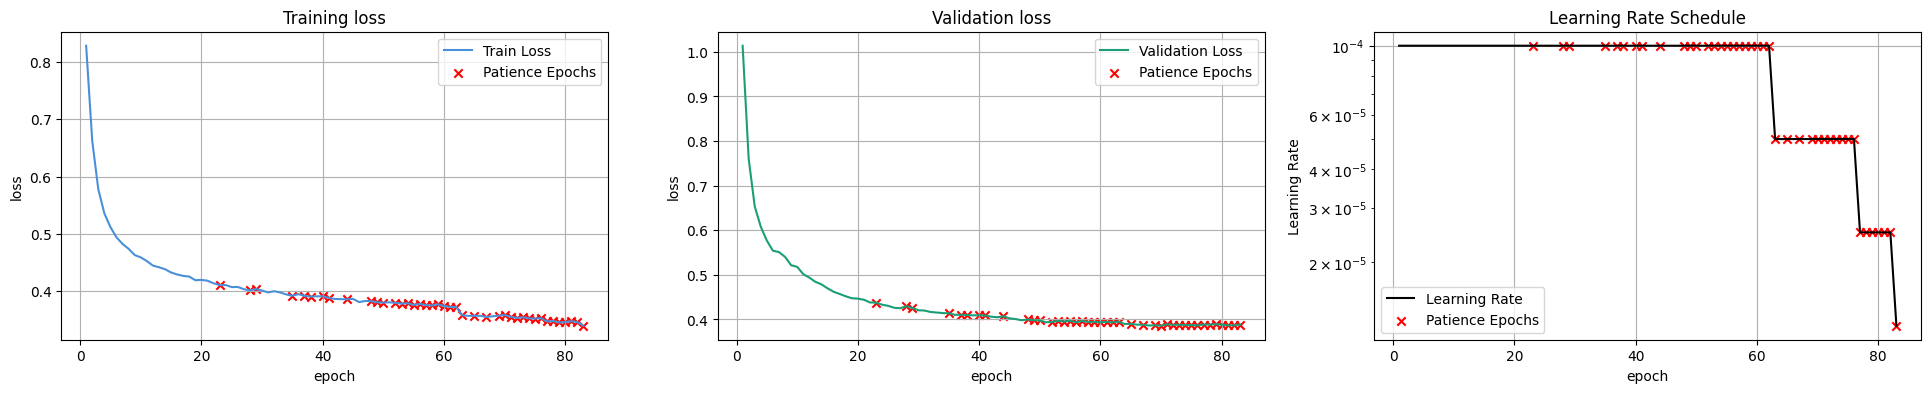

In [ ]:
ml3 = GCNTCNModel(graphdataloader_2, name = 'model3',verbose = 2)
ml3.set_model_hparams(norm_edges=True)
ml3.set_global_hparams(**global_hparams)
ml3.train()
ml3.forecast()


==                    model4                    ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 25, 4), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   0.8303   |   0.9097   |    v     |           |
|  002  |   0.6489   |   0.6845   |    v     |           |
|  003  |   0.5785   |   0.6214   |    v     |           |
|  004  |   0.5335   |   0.5871   |    v     |           |
|  005  |   0.5055   |   0.5640   |    v     |           |
|  006  |   0.4848   |   0.5540   |    v     |           |
|  007  |   0.4723   |   0.5519   |    v     |           |
|  008  |   0.4655   |   0.5385   |    v     |           |
|  009  |   0.4547   |   0.5316   |    v     |           |
|  010  |   0.4489   |   0.5318   |          |   1/15    |
|  011  |   0.4415   |   0.5211   |    v     |           |
|  012  |   0.4366   |   0.5138   |    v

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:335: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 15 epochs
Restored model from best validation loss: 0.3804
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 444.17it/s]

Test loss: 0.6000
forecasted ✓


GCNTCNModel(name='model4')

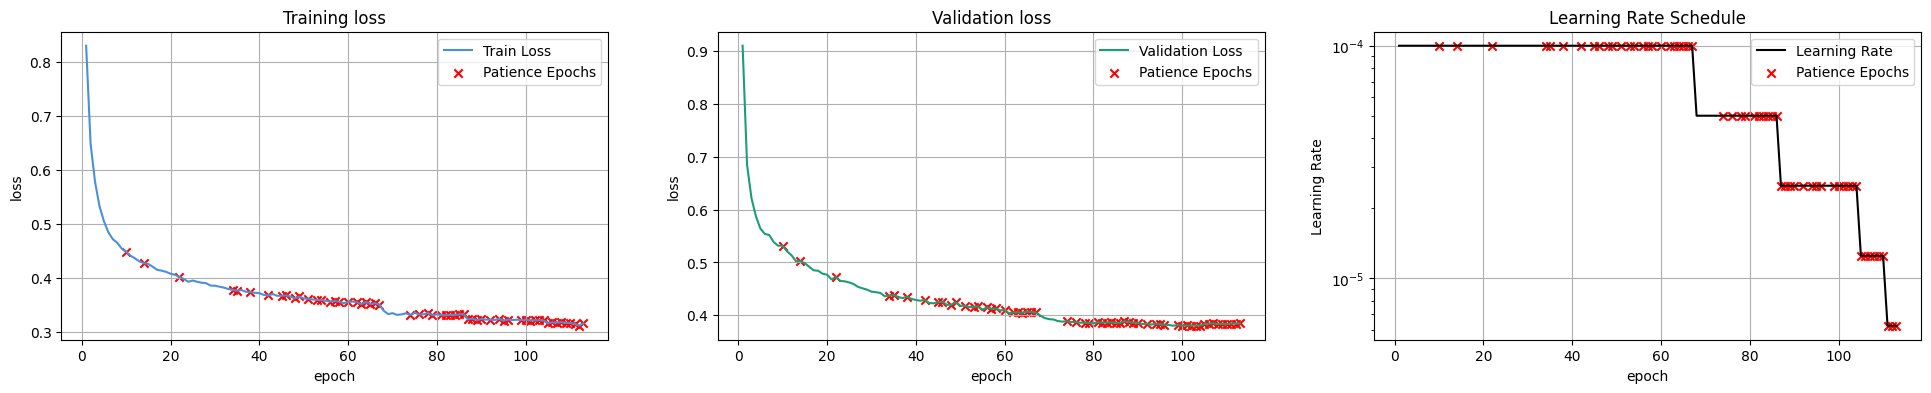

In [ ]:
ml4 = GCNTCNModel(graphdataloader_3, name = 'model4',verbose = 2)
ml4.set_model_hparams(norm_edges = True)
ml4.set_global_hparams(**global_hparams)
ml4.train()
ml4.forecast()


==                    model5                    ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 25, 4), y=(400, 1), edge_index=(2, 160000), edge_weight=(160000,))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   0.8827   |   1.0347   |    v     |           |
|  002  |   0.7169   |   0.8512   |    v     |           |
|  003  |   0.6531   |   0.7433   |    v     |           |
|  004  |   0.6016   |   0.6806   |    v     |           |
|  005  |   0.5673   |   0.6436   |    v     |           |
|  006  |   0.5471   |   0.6161   |    v     |           |
|  007  |   0.5293   |   0.6040   |    v     |           |
|  008  |   0.5174   |   0.5785   |    v     |           |
|  009  |   0.5089   |   0.5650   |    v     |           |
|  010  |   0.5030   |   0.5570   |    v     |           |
|  011  |   0.4989   |   0.5434   |    v     |           |
|  012  |   0.4895   |   0.5328   

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:335: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 15 epochs
Restored model from best validation loss: 0.4614
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 450.93it/s]


Test loss: 0.6389
forecasted ✓


GCNTCNModel(name='model5')

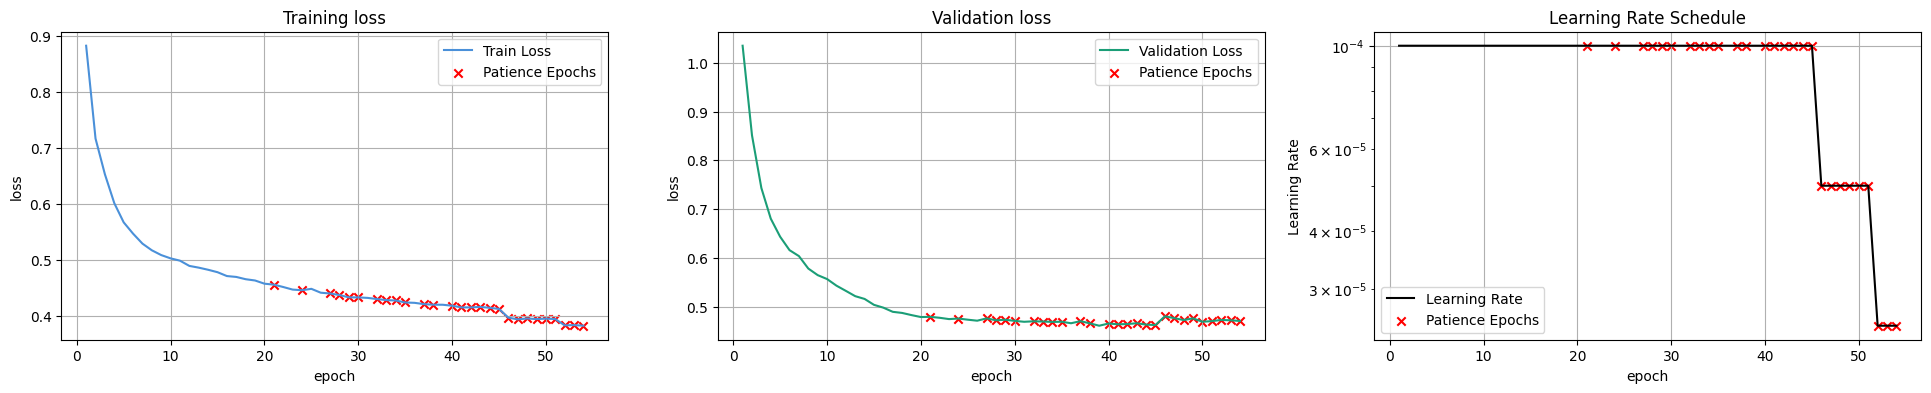

In [ ]:
ml5 = GCNTCNModel(graphdataloader_4, name = 'model5',verbose = 2)
ml5.set_model_hparams()
ml5.set_global_hparams(**global_hparams)
ml5.train()
ml5.forecast()


==                    model6                    ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: DeepData(x=(400, 25, 4), y=(400, 1))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   0.8691   |   1.3863   |    v     |           |
|  002  |   0.6594   |   0.7531   |    v     |           |
|  003  |   0.6376   |   0.7151   |    v     |           |
|  004  |   0.5685   |   0.6193   |    v     |           |
|  005  |   0.5360   |   0.5782   |    v     |           |
|  006  |   0.5037   |   0.5396   |    v     |           |
|  007  |   0.4787   |   0.5158   |    v     |           |
|  008  |   0.4597   |   0.5001   |    v     |           |
|  009  |   0.4464   |   0.4875   |    v     |           |
|  010  |   0.4374   |   0.4773   |    v     |           |
|  011  |   0.4266   |   0.4667   |    v     |           |
|  012  |   0.4218   |   0.4618   |    v     |           |
|  013  |   0.4166   | 

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:335: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 15 epochs
Restored model from best validation loss: 0.3674
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 937.18it/s]

Test loss: 0.5655
forecasted ✓


LSTMModel(name='model6')

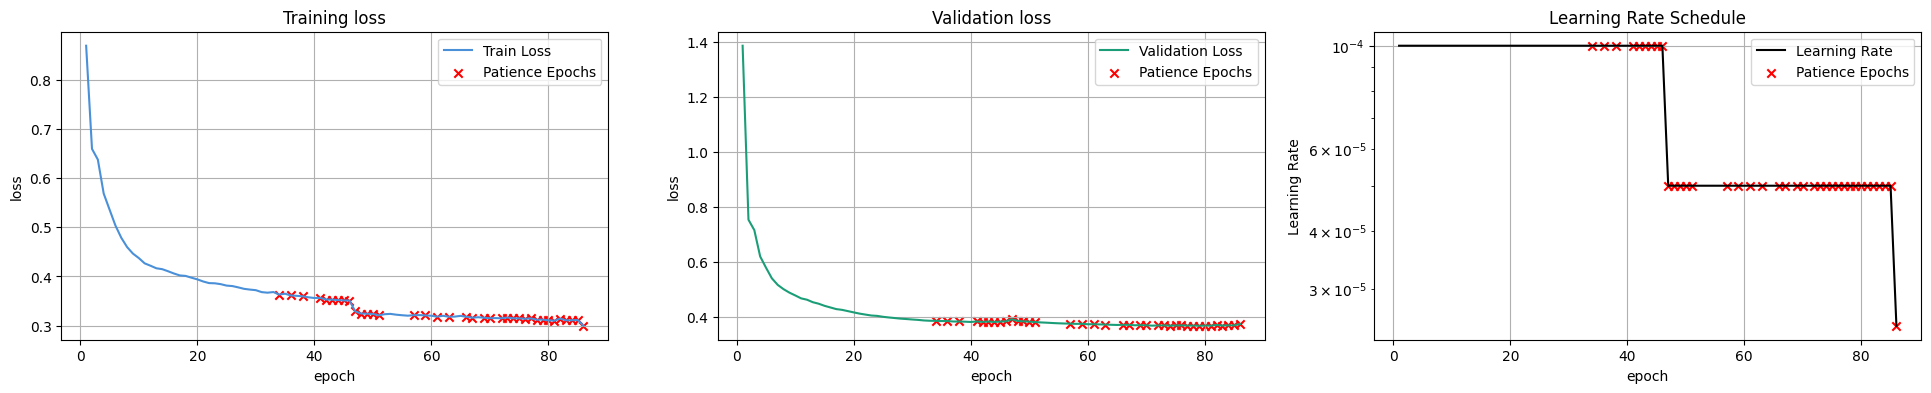

In [ ]:
ml5 = LSTMModel(deepdataloader, name = 'model6',verbose = 2)
ml5.set_model_hparams()
ml5.set_global_hparams(**global_hparams)
ml5.train()
ml5.forecast()

  3%|████▌                                                                                                                                                                 | 66/2400 [00:00<00:03, 657.91it/s]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2400/2400 [00:02<00:00, 811.77it/s]
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:153: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)


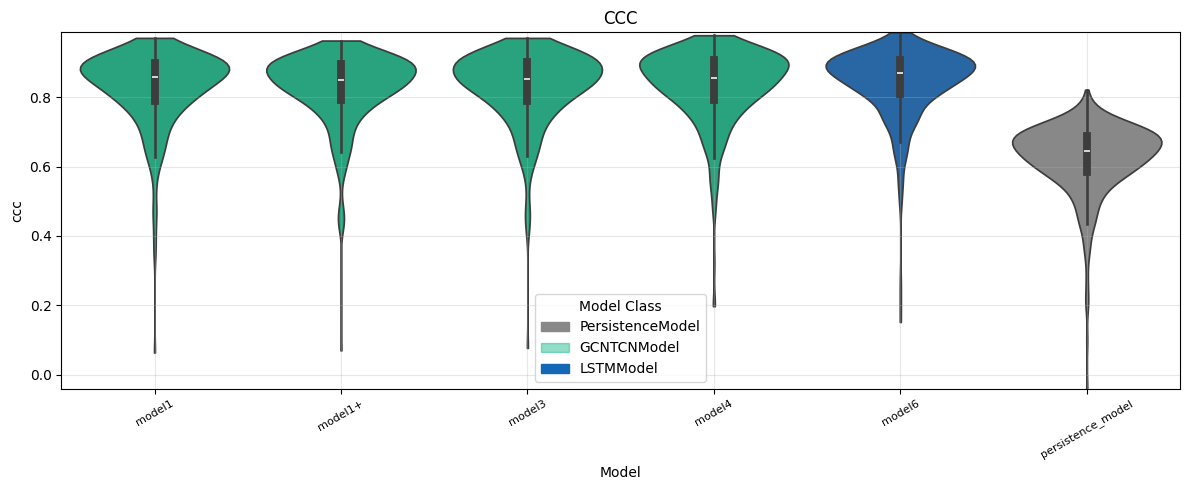

In [ ]:
evaluation_experiment_sgnn = Evaluator(baseline_models + [ml1, ml2, ml3, ml4, ml5]).add_evaluation()
f = evaluation_experiment_sgnn.plotter.plot_single_metric('wis',0,plot_type = 'violin',reverse_scale=True)
f.show()


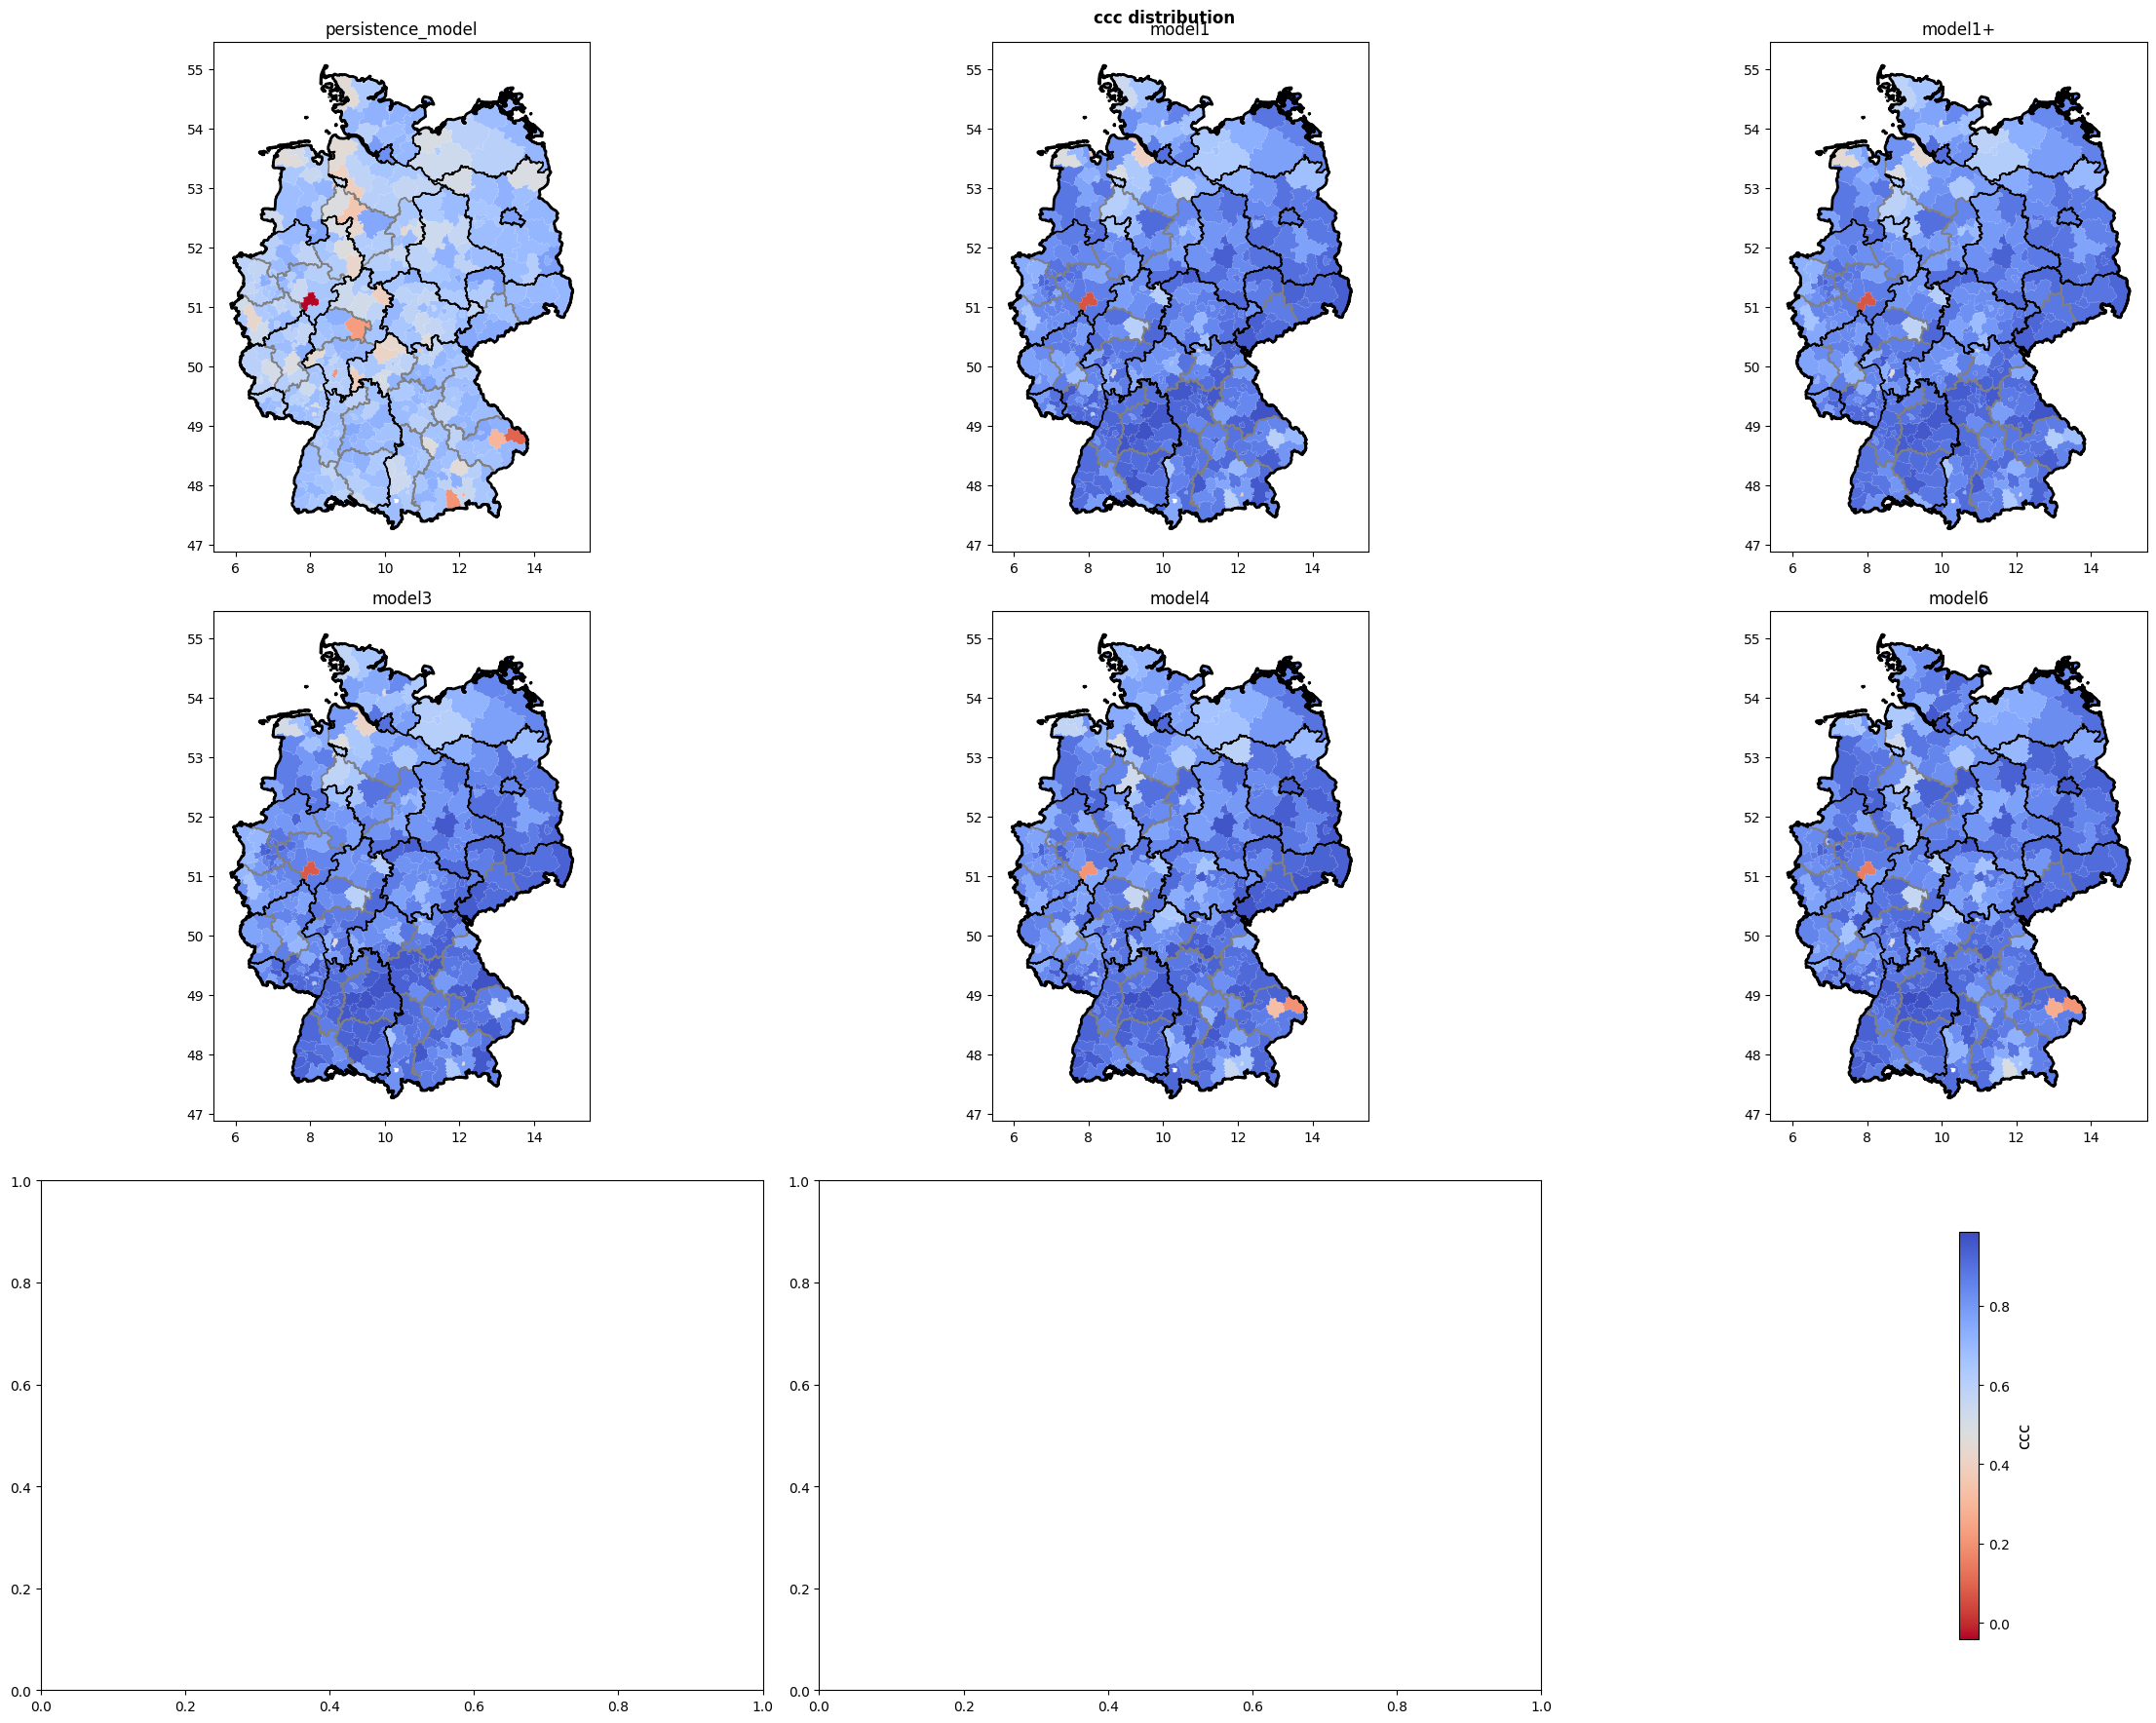

In [ ]:
evaluation_experiment_sgnn.plotter.plot_single_metric('wis',0,plot_type = 'map',reverse_scale=True,vmin = 0)

In [ ]:
df = evaluation_experiment_sgnn.data_compilation.get_data(0,'test')['metrics']
df_comp = df[df['model'].isin(['model3','model6'])][['nuts_node','model','r2','ccc']]
df_comp_ccc = df_comp[['nuts_node','model','ccc']].pivot_table(index = 'nuts_node', columns = 'model', values = 'ccc').reset_index(drop = False)
df_comp_r2 = df_comp[['nuts_node','model','r2']].pivot_table(index = 'nuts_node', columns = 'model', values = 'r2').reset_index(drop = False)

df_comp_ccc['diff'] = 100 * (df_comp_ccc['model3'] - df_comp_ccc['model6']) / df_comp_ccc['model3']
df_comp_r2['diff'] = 100 * (df_comp_r2['model3'] - df_comp_r2['model6']) / df_comp_r2['model3']

gdf = epidata_orchestrator.data_context.shapedata_node
import pandas as pd
df_comp_ccc = pd.merge(gdf, df_comp_ccc, on = 'nuts_node')
df_comp_r2 = pd.merge(gdf, df_comp_r2, on = 'nuts_node')

<Axes: >

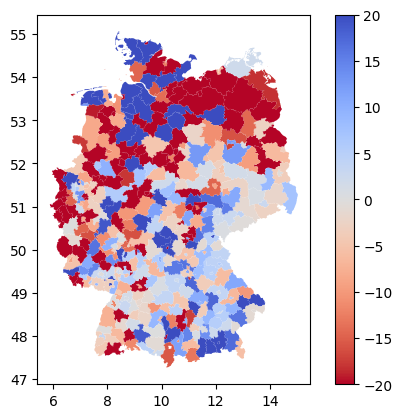

In [ ]:
df_comp_r2.plot(column = 'diff', cmap = 'coolwarm_r', vmin = -20, vmax = 20, legend = True)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd 
import geopandas as gpd

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a c

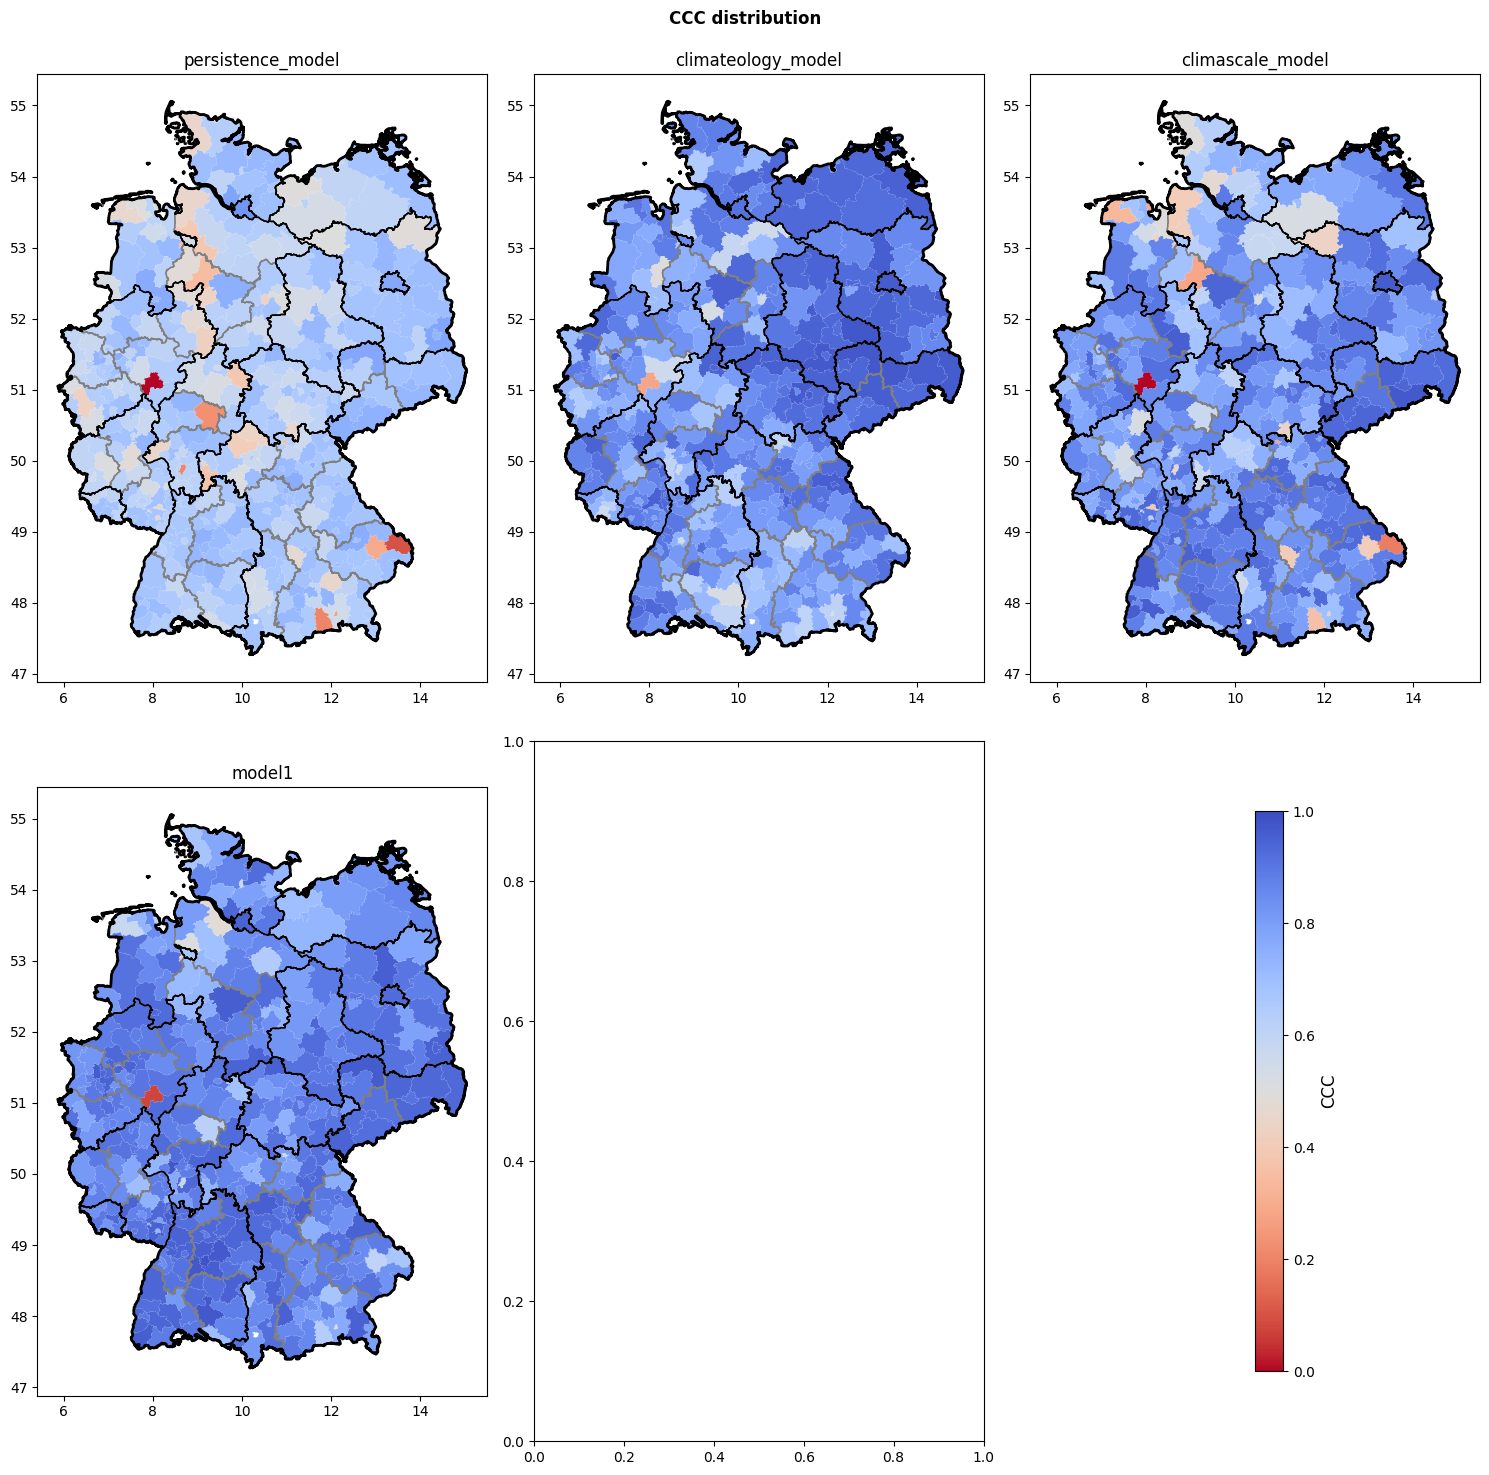

In [ ]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

metric_df = ccc

fig, axes = plt.subplots(2, 3, figsize=(15, 15))
axes = axes.flatten()

ctx = epidata_orchestrator.data_context



map_df = gpd.GeoDataFrame(pd.merge(metric_df, gdf, on=['nuts_node']))

for idx, model in enumerate(list(metric_df.columns[1:])):

    data = map_df[['nuts_node', 'geometry', model]]
    data[model] = pd.to_numeric(data[model])
    data.plot(
        ax=axes[idx],
        column=model,
        cmap='coolwarm_r',
        vmin=0,
        vmax=1,
        legend=False       # no legend on any subplot
    )

    ctx.shapedata_nuts2.plot(ax = axes[idx], facecolor = 'none', linewidth = 1, edgecolor = 'grey')
    ctx.shapedata_nuts1.plot(ax = axes[idx], facecolor = 'none', linewidth = 1, edgecolor = 'black')
    ctx.shapedata_nuts0.plot(ax = axes[idx], facecolor = 'none', linewidth = 2, edgecolor = 'black')    
    axes[idx].set_title(model)

# --- colorbar in the last (empty) axis ---
last_ax = axes[-1]
last_ax.set_visible(False)          # hide the map frame/ticks

sm = ScalarMappable(cmap='coolwarm_r', norm=Normalize(vmin=0, vmax=1))
sm.set_array([])                    # required boilerplate

cbar = fig.colorbar(
    sm,
    ax=last_ax,                     # anchor to the empty axis
    fraction=0.5,                   # how much of the axis the cbar fills
    shrink=0.8,
    pad=0.05
)
cbar.set_label('CCC', fontsize=12)

fig.suptitle('CCC distribution', fontweight = 'bold')

plt.tight_layout()
plt.show()

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a c

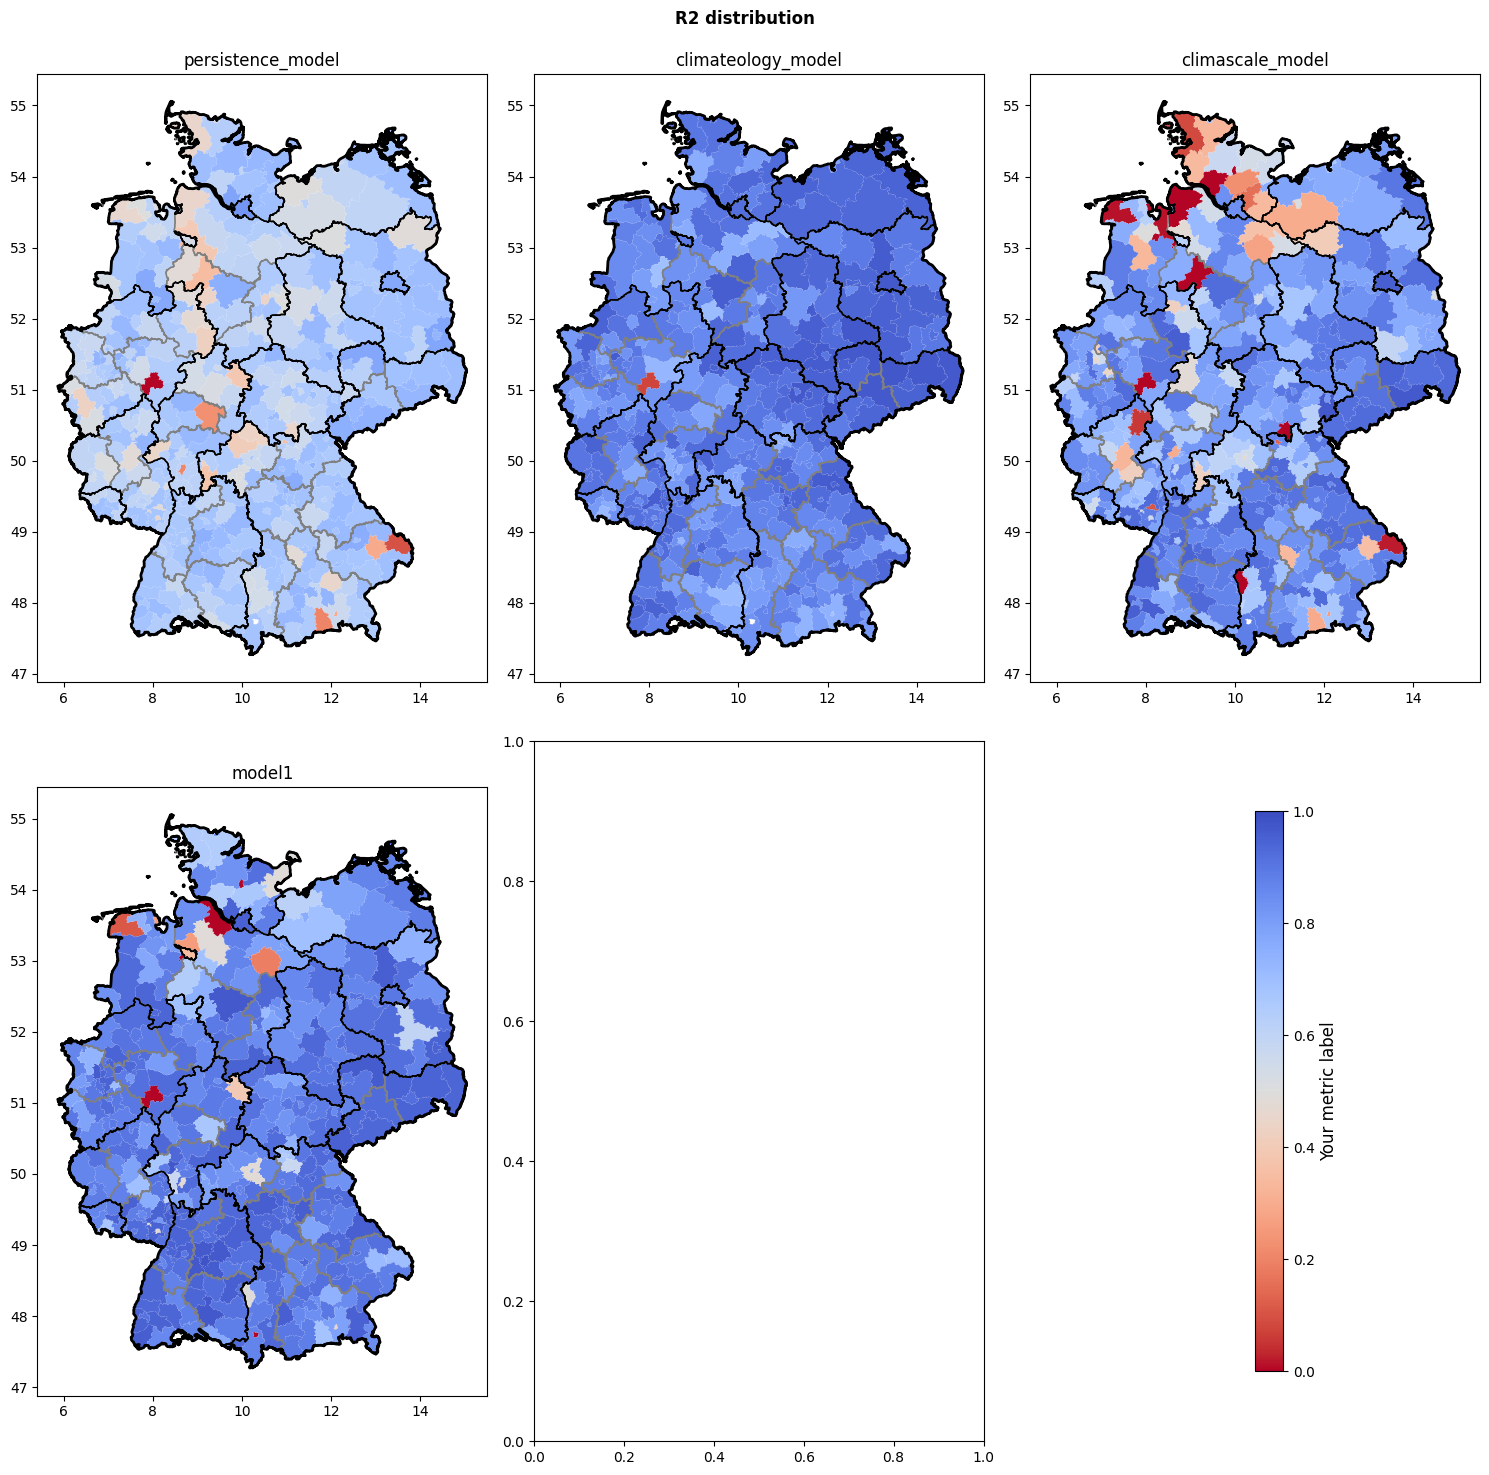

In [ ]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

metric_df = r2

fig, axes = plt.subplots(2, 3, figsize=(15, 15))
axes = axes.flatten()

ctx = epidata_orchestrator.data_context



map_df = gpd.GeoDataFrame(pd.merge(metric_df, gdf, on=['nuts_node']))

for idx, model in enumerate(list(metric_df.columns[1:])):

    data = map_df[['nuts_node', 'geometry', model]]
    data[model] = pd.to_numeric(data[model])
    data.plot(
        ax=axes[idx],
        column=model,
        cmap='coolwarm_r',
        vmin=-1,
        vmax=1,
        legend=False       # no legend on any subplot
    )

    ctx.shapedata_nuts2.plot(ax = axes[idx], facecolor = 'none', linewidth = 1, edgecolor = 'grey')
    ctx.shapedata_nuts1.plot(ax = axes[idx], facecolor = 'none', linewidth = 1, edgecolor = 'black')
    ctx.shapedata_nuts0.plot(ax = axes[idx], facecolor = 'none', linewidth = 2, edgecolor = 'black')    
    axes[idx].set_title(model)

# --- colorbar in the last (empty) axis ---
last_ax = axes[-1]
last_ax.set_visible(False)          # hide the map frame/ticks

sm = ScalarMappable(cmap='coolwarm_r', norm=Normalize(vmin=0, vmax=1))
sm.set_array([])                    # required boilerplate

cbar = fig.colorbar(
    sm,
    ax=last_ax,                     # anchor to the empty axis
    fraction=0.5,                   # how much of the axis the cbar fills
    shrink=0.8,
    pad=0.05
)
cbar.set_label('Your metric label', fontsize=12)

fig.suptitle('R2 distribution',fontweight = 'bold')
plt.tight_layout()
plt.show()